In [1]:
import os
import sys
lib_svraster = "/home/dotamthuc/Works/Projects/Compress3DGS/svraster"
sys.path.insert(0, lib_svraster)

import json
import pandas as pd 
import numpy as np
from PIL import Image
from tqdm import trange
from pathlib import Path

import torch

from src.utils.image_utils import im_pil2tensor
from src.utils.loss_utils import psnr_score, ssim_score, lpips_loss, correct_lpips_loss, l2_loss


def read_pairs(renders_dir, gt_dir):
    renders = []
    gts = []
    image_names = []
    for fname in os.listdir(renders_dir):
        render = Image.open(f"{renders_dir}/{fname}")
        gt = Image.open(f"{gt_dir}/{fname}")
        renders.append(im_pil2tensor(render).unsqueeze(0))
        gts.append(im_pil2tensor(gt).unsqueeze(0))
        image_names.append(fname)
    return renders, gts, image_names


def evaluate(render_path):

    renders, gts, image_names = read_pairs(
        renders_dir=f"{render_path}/renders",
        gt_dir=f"{render_path}/gt"
    )

    mses = []
    ssims = []
    psnrs = []
    lpipss = []
    correct_lpipss = []

    for idx in trange(len(renders)):
        im_render = renders[idx].cuda()
        im_gt = gts[idx].cuda()
        mses.append(l2_loss(im_render, im_gt).item())
        ssims.append(ssim_score(im_render, im_gt).item())
        psnrs.append(psnr_score(im_render, im_gt).item())
        lpipss.append(lpips_loss(im_render, im_gt).item())
        correct_lpipss.append(correct_lpips_loss(im_render, im_gt).item())
        del im_render, im_gt
        torch.cuda.empty_cache()

    avg_mse = np.mean(mses)
    avg_ssim = np.mean(ssims)
    avg_psnr = np.mean(psnrs)
    avg_lpips = np.mean(lpipss)
    avg_correct_lpips = np.mean(correct_lpipss)

    # print(f"   MSE : {avg_mse:>12.7f}")
    # print(f"  SSIM : {avg_ssim:>12.7f}")
    # print(f"  PSNR : {avg_psnr:>12.7f}")
    # print(f"  LPIPS: {avg_lpips:>12.7f}")
    # print(f"  LPIPS: {avg_correct_lpips:>12.7f} (corrected)")
    # print("")

    results = {
        "mse": avg_mse,
        "ssim": avg_ssim,
        "psnr": avg_psnr,
        "lpips": avg_lpips,
        "correct_lpips": avg_correct_lpips,
    }
    results_per_view= {
        "MSE": {name: mse for mse, name in zip(mses, image_names)},
        "SSIM": {name: ssim for ssim, name in zip(ssims, image_names)},
        "PSNR": {name: psnr for psnr, name in zip(psnrs, image_names)},
        "LPIPS": {name: lp for lp, name in zip(lpipss, image_names)},
        "LPIPS-corrected": {name: lp for lp, name in zip(correct_lpipss, image_names)},
    }

    return results, results_per_view



# OUR MODELS

In [ ]:
output_path = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/"
base_configs = [
    ("SVRasterCompressed", ["nerf_synthetic"]),
    ("SVRasterCompressed-DirColorv", ["nerf_synthetic"]),
    ("SVRasterCompressed-NoShsTransform", ["nerf_synthetic"]),
    # ("SVRasterSmallCompressed", ["mip-nerf-360"]),
    # ("SVRasterSmallCompressed-DirColorv", ["mip-nerf-360"]),
    # ("SVRasterSmallCompressed-NoShsTransform", ["mip-nerf-360"]),
]
scene_list = {
    "mip-nerf-360": ["bicycle", "bonsai", "counter", "flowers", "garden", "kitchen", "room", "stump", "treehill"],
    "nerf_synthetic": ["chair", "drums", "ficus", "hotdog", "lego", "materials", "mic", "ship"],
}

config_list = ["config01", "config02", "config03", "config04", "config05", "config06"]



In [ ]:

for method, list_dataset_name in base_configs:
    final_pdf = []
    for dataset_name in list_dataset_name:
        scenes = scene_list[dataset_name]
        for scene in scenes:
            for config in config_list:
                path_model = f"{output_path}/{method}/{dataset_name}/{scene}/{config}"
                print("path_model:", path_model)
                size = 0.0
                size = os.path.getsize(f"{path_model}/compressed_bitstream/meta_info.npz")
                size += os.path.getsize(f"{path_model}/compressed_bitstream/occupacy_bitstreams.npz")
                size += os.path.getsize(f"{path_model}/compressed_bitstream/geoparams_bitstreams.npz")
                size += os.path.getsize(f"{path_model}/compressed_bitstream/color_inverse_transform.npz")
                size += os.path.getsize(f"{path_model}/compressed_bitstream/color_coefs_bitsteams.npz")

                results, results_per_view = evaluate(
                    f"{path_model}/test/"
                )

                row = {}
                row["method"] = method
                row["dataset"] = dataset_name
                row["config"] = config
                row["scene_name"] = scene
                row["Size_Bytes"] = size
                row["Size_MB"] = size/1024/1024
                row.update(results)

                print(f"  method : {row['method']}")
                print(f" dataset : {row['dataset']}")
                print(f"  config : {row['config']}")
                print(f"   scene : {row['scene_name']}")
                print(f"    Size : {row['Size_MB']:>12.7f} MB")
                print(f"     MSE : {row['mse']:>12.7f}")
                print(f"    SSIM : {row['ssim']:>12.7f}")
                print(f"    PSNR : {row['psnr']:>12.7f}")
                print(f"   LPIPS : {row['lpips']:>12.7f}")
                print(f"   LPIPS : {row['correct_lpips']:>12.7f} (corrected)")
                print("")
                final_pdf.append(row)

    df = pd.DataFrame(final_pdf)
    df.to_csv(f'/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/SVComression/results_V01_nerf_synthetic_{method}.csv', index=False)


    

# MESON-GS

In [55]:
output_path = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output"
base_configs = [
    ("MesonGS", ["nerf_synthetic"]),
]
scene_list = {
    "mip-nerf-360": ["bicycle", "bonsai", "counter", "flowers", "garden", "kitchen", "room", "stump", "treehill"],
    "nerf_synthetic": ["chair", "drums", "ficus", "hotdog", "lego", "materials", "mic", "ship"],
}

config_list = [
    ("config3", "iteration_0"),
    ("config3", "iteration_400"), 
    ("universal", "iteration_0"), 
    ("universal", "iteration_400"), 
]





In [ ]:

for method, list_dataset_name in base_configs:
    final_pdf = []
    for dataset_name in list_dataset_name:
        scenes = scene_list[dataset_name]
        for scene in scenes:
            for config, iter_name in config_list:
                path_model = f"{output_path}/{method}/{config}/{dataset_name}/{scene}"
                print("path_model:", path_model)
                size = 0.0
                size = os.path.getsize(f"{path_model}/point_cloud/{iter_name}/pc_npz/bins.zip")

                results, results_per_view = evaluate(
                    f"{path_model}/test/{iter_name}"
                )

                row = {}
                row["method"] = method
                row["dataset"] = dataset_name
                row["config"] = f"{config}_{iter_name}"
                row["scene_name"] = scene
                row["Size_Bytes"] = size
                row["Size_MB"] = size/1024/1024
                row.update(results)

                print(f"  method : {row['method']}")
                print(f" dataset : {row['dataset']}")
                print(f"  config : {row['config']}")
                print(f"   scene : {row['scene_name']}")
                print(f"    Size : {row['Size_MB']:>12.7f} MB")
                print(f"     MSE : {row['mse']:>12.7f}")
                print(f"    SSIM : {row['ssim']:>12.7f}")
                print(f"    PSNR : {row['psnr']:>12.7f}")
                print(f"   LPIPS : {row['lpips']:>12.7f}")
                print(f"   LPIPS : {row['correct_lpips']:>12.7f} (corrected)")
                print("")
                final_pdf.append(row)
    #             break
    #         break
    #     break
    # break


    df = pd.DataFrame(final_pdf)
    df.to_csv(f'/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/MesonGS/results_mesonGS_{dataset_name}_{method}.csv', index=False)


    

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/MesonGS/config3/nerf_synthetic/chair


100%|██████████| 200/200 [00:24<00:00,  8.24it/s]


# SVRaster

In [83]:
output_path = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output"
base_configs = [
    ("SVRaster", ["nerf_synthetic"]),
    # ("SVRasterSmall", ["mip-nerf-360"]),
]
scene_list = {
    "mip-nerf-360": ["bicycle", "bonsai", "counter", "flowers", "garden", "kitchen", "room", "stump", "treehill"],
    "nerf_synthetic": ["chair", "drums", "ficus", "hotdog", "lego", "materials", "mic", "ship"],
}

config_list = ["ours_30000"]



for method, list_dataset_name in base_configs:
    final_pdf = []
    for dataset_name in list_dataset_name:
        scenes = scene_list[dataset_name]
        for scene in scenes:
            for config in config_list:
                path_model = f"{output_path}/{method}/{dataset_name}/{scene}"
                print("path_model:", path_model)
                size = 0.0
                size = os.path.getsize(f"{path_model}/checkpoints/iter030000_model.pt")

                results, results_per_view = evaluate(
                    f"{path_model}/test/{config}"
                )

                row = {}
                row["method"] = method
                row["dataset"] = dataset_name
                row["config"] = f"{config}"
                row["scene_name"] = scene
                row["Size_Bytes"] = size
                row["Size_MB"] = size/1024/1024
                row.update(results)

                print(f"  method : {row['method']}")
                print(f" dataset : {row['dataset']}")
                print(f"  config : {row['config']}")
                print(f"   scene : {row['scene_name']}")
                print(f"    Size : {row['Size_MB']:>12.7f} MB")
                print(f"     MSE : {row['mse']:>12.7f}")
                print(f"    SSIM : {row['ssim']:>12.7f}")
                print(f"    PSNR : {row['psnr']:>12.7f}")
                print(f"   LPIPS : {row['lpips']:>12.7f}")
                print(f"   LPIPS : {row['correct_lpips']:>12.7f} (corrected)")
                print("")
                final_pdf.append(row)
    #             break
    #         break
    #     break
    # break


    df = pd.DataFrame(final_pdf)
    df.to_csv(f'/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/SVRaster/results_big_{dataset_name}_{method}.csv', index=False)



path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/nerf_synthetic/chair


100%|██████████| 200/200 [00:26<00:00,  7.67it/s]


  method : SVRaster
 dataset : nerf_synthetic
  config : ours_30000
   scene : chair
    Size :  574.0729179 MB
     MSE :    0.0002710
    SSIM :    0.9862839
    PSNR :   35.9550606
   LPIPS :    0.0124883
   LPIPS :    0.0169285 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/nerf_synthetic/drums


100%|██████████| 200/200 [00:25<00:00,  7.72it/s]


  method : SVRaster
 dataset : nerf_synthetic
  config : ours_30000
   scene : drums
    Size :  454.1219902 MB
     MSE :    0.0027413
    SSIM :    0.9466198
    PSNR :   26.0974920
   LPIPS :    0.0429694
   LPIPS :    0.0514143 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/nerf_synthetic/ficus


...

  method : SVRaster
 dataset : nerf_synthetic
  config : ours_30000
   scene : materials
    Size :  536.4880180 MB
     MSE :    0.0011379
    SSIM :    0.9539084
    PSNR :   30.0036739
   LPIPS :    0.0376516
   LPIPS :    0.0466269 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/nerf_synthetic/mic


100%|██████████| 200/200 [00:26<00:00,  7.61it/s]


  method : SVRaster
 dataset : nerf_synthetic
  config : ours_30000
   scene : mic
    Size :  222.3605766 MB
     MSE :    0.0002652
    SSIM :    0.9919624
    PSNR :   36.1426513
   LPIPS :    0.0067202
   LPIPS :    0.0089827 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/SVRaster/nerf_synthetic/ship


100%|██████████| 200/200 [00:26<00:00,  7.48it/s]

  method : SVRaster
 dataset : nerf_synthetic
  config : ours_30000
   scene : ship
    Size : 1155.9606743 MB
     MSE :    0.0010177
    SSIM :    0.8854070
    PSNR :   30.4543837
   LPIPS :    0.1059718
   LPIPS :    0.1235220 (corrected)



# Compact3DGS

In [3]:
output_path = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output"
base_configs = [
    ("Compact3DGS", ["mip-nerf-360"]),
    # ("Compact3DGS", ["nerf_synthetic"]),
]
scene_list = {
    "mip-nerf-360": ["bicycle", "bonsai", "counter", "flowers", "garden", "kitchen", "room", "stump", "treehill"],
    "nerf_synthetic": ["chair", "drums", "ficus", "hotdog", "lego", "materials", "mic", "ship"],
}

config_list = ["config00", "config01", "config02"]

for method, list_dataset_name in base_configs:
    final_pdf = []
    for dataset_name in list_dataset_name:
        scenes = scene_list[dataset_name]
        for scene in scenes:
            for config in config_list:
                path_model = f"{output_path}/{method}/{dataset_name}/{scene}/{config}"
                print("path_model:", path_model)
                size = 0.0
                size = os.path.getsize(f"{path_model}/point_cloud/iteration_30000/point_cloud_pp.npz")

                results, results_per_view = evaluate(
                    f"{path_model}/test/ours_30000"
                )

                row = {}
                row["method"] = method
                row["dataset"] = dataset_name
                row["config"] = f"{config}"
                row["scene_name"] = scene
                row["Size_Bytes"] = size
                row["Size_MB"] = size/1024/1024
                row.update(results)

                print(f"  method : {row['method']}")
                print(f" dataset : {row['dataset']}")
                print(f"  config : {row['config']}")
                print(f"   scene : {row['scene_name']}")
                print(f"    Size : {row['Size_MB']:>12.7f} MB")
                print(f"     MSE : {row['mse']:>12.7f}")
                print(f"    SSIM : {row['ssim']:>12.7f}")
                print(f"    PSNR : {row['psnr']:>12.7f}")
                print(f"   LPIPS : {row['lpips']:>12.7f}")
                print(f"   LPIPS : {row['correct_lpips']:>12.7f} (corrected)")
                print("")
                final_pdf.append(row)
    #         break
    #     break
    # break


    df = pd.DataFrame(final_pdf)
    df.to_csv(f'/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/Compact3DGS/results_{dataset_name}_{method}.csv', index=False)



path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/Compact3DGS/mip-nerf-360/bicycle/config00


  0%|          | 0/25 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/dotamthuc/miniconda3/envs/VoxelSplat/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dotamthuc/miniconda3/envs/VoxelSplat/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/dotamthuc/miniconda3/envs/VoxelSplat/lib/python3.9/site-packages/lpips/weights/v0.1/vgg.pth


...

  method : Compact3DGS
 dataset : mip-nerf-360
  config : config00
   scene : treehill
    Size :   33.2097654 MB
     MSE :    0.0064644
    SSIM :    0.6348035
    PSNR :   22.6185076
   LPIPS :    0.3618571
   LPIPS :    0.4220349 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/Compact3DGS/mip-nerf-360/treehill/config01


100%|██████████| 18/18 [00:05<00:00,  3.25it/s]


  method : Compact3DGS
 dataset : mip-nerf-360
  config : config01
   scene : treehill
    Size :   23.0924320 MB
     MSE :    0.0068269
    SSIM :    0.6151615
    PSNR :   22.3229327
   LPIPS :    0.3993645
   LPIPS :    0.4635941 (corrected)

path_model: /home/dotamthuc/Works/Projects/Compress3DGS/Experiments/output/Compact3DGS/mip-nerf-360/treehill/config02


100%|██████████| 18/18 [00:05<00:00,  3.20it/s]

  method : Compact3DGS
 dataset : mip-nerf-360
  config : config02
   scene : treehill
    Size :   19.9850492 MB
     MSE :    0.0075269
    SSIM :    0.5778693
    PSNR :   21.8418056
   LPIPS :    0.4477952
   LPIPS :    0.5107090 (corrected)



# PLOTS

In [2]:
import pandas as pd
import matplotlib.pylab as plt

results_csv_folder = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/"

#
df_SVRaster = pd.read_csv(f"{results_csv_folder}/SVRaster/results_big_mip-nerf-360_SVRaster.csv")
df_SVRaster_small = pd.read_csv(f"{results_csv_folder}/SVRaster/results_small_mip-nerf-360_SVRasterSmall.csv")

#
df_mesonGS = pd.read_csv(f"{results_csv_folder}/MesonGS/results_mesonGS_mip-nerf-360_MesonGS.csv")

df_compact3DGS = pd.read_csv(f"{results_csv_folder}/Compact3DGS/results_mip-nerf-360_Compact3DGS.csv")

#
df_SVRasterCompressed_DirColorv           = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterCompressed-DirColorv.csv")
df_SVRasterCompressed_NoShsTransform      = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterCompressed-NoShsTransform.csv")
df_SVRasterCompressed                     = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterCompressed.csv")
df_SVRasterSmallCompressed_DirColorv      = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterSmallCompressed-DirColorv.csv")
df_SVRasterSmallCompressed_NoShsTransform = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterSmallCompressed-NoShsTransform.csv")
df_SVRasterSmallCompressed                = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_SVRasterSmallCompressed.csv")

In [4]:
df_compact3DGS.query("config=='config01'")

,method,dataset,config,scene_name,Size_Bytes,Size_MB,mse,ssim,psnr,lpips,correct_lpips
1,Compact3DGS,mip-nerf-360,config01,bicycle,25962790,24.760046,0.004585,0.690424,24.044488,0.319231,0.359830
4,Compact3DGS,mip-nerf-360,config01,bonsai,12043693,11.485761,0.000977,0.920909,30.763812,0.219654,0.282011
7,Compact3DGS,mip-nerf-360,config01,counter,11156487,10.639655,0.001711,0.883525,27.946234,0.231864,0.300106
10,Compact3DGS,mip-nerf-360,config01,flowers,20039085,19.110761,0.009248,0.522976,20.401395,0.421442,0.455750
13,Compact3DGS,mip-nerf-360,config01,garden,26083676,24.875332,0.002852,0.814055,26.287515,0.182919,0.212467
16,Compact3DGS,mip-nerf-360,config01,kitchen,15820970,15.088053,0.001159,0.906827,29.785251,0.148011,0.183295
19,Compact3DGS,mip-nerf-360,config01,room,10960366,10.452620,0.001277,0.909217,30.259153,0.228324,0.309366
22,Compact3DGS,mip-nerf-360,config01,stump,21812301,20.801831,0.003158,0.704621,25.395787,0.343911,0.388048
25,Compact3DGS,mip-nerf-360,config01,treehill,24214170,23.092432,0.006827,0.615161,22.322933,0.399365,0.463594


In [13]:

list_mb=[]
list_psnr=[]
points = ["config=='config00'", "config=='config01'", "config=='config02'"]
for query in points:
    print(f"compact3DGS query={query}")
    size, psnr = df_compact3DGS.query(query)[["Size_MB", "mse"]].mean()
    list_mb.append(size)
    list_psnr.append(psnr)

print(list_mb)
print(list_psnr)



compact3DGS query=config=='config00'
compact3DGS query=config=='config01'
compact3DGS query=config=='config02'
[24.984521865844727, 17.811832216050888, 15.416125297546387]
[0.0031286701518001107, 0.0035324802615301107, 0.004493798714191433]


In [9]:
df_compact3DGS.query("config=='config02'")[["Size_MB", "psnr", "ssim", "lpips"]].mean()


Size_MB    15.416125
psnr       24.957426
ssim        0.720430
lpips       0.342233
dtype: float64

In [ ]:
Size_MB    15.4161
psnr       24.9574
ssim        0.7204
lpips       0.3422

In [ ]:

list_mb=[]
list_psnr=[]
points = ["config=='config3_iteration_0'", "config=='universal_iteration_0'"]
for query in points:
    print(f"MesonGS query={query}")
    size, psnr = df_mesonGS.query(query)[["Size_MB", "psnr"]].mean()
    list_mb.append(size)
    list_psnr.append(psnr)

print(list_mb)
print(list_psnr)



MesonGS query=config=='config3_iteration_0'


ValueError: too many values to unpack (expected 2)

In [53]:
df_mesonGS.query("config=='config3_iteration_0'")[["Size_MB", "psnr", "ssim", "lpips"]].mean()

Size_MB    28.334910
psnr       25.962563
ssim        0.769015
lpips       0.266647
dtype: float64

In [ ]:
Size_MB    28.3349
psnr       25.9625
ssim        0.7690
lpips       0.2666

In [6]:
# df_SVRasterCompressed_DirColorv
# df_SVRasterCompressed_NoShsTransform
# df_SVRasterCompressed
# df_SVRasterSmallCompressed_DirColorv
# df_SVRasterSmallCompressed_NoShsTransform
# df_SVRasterSmallCompressed

list_mb=[]
list_psnr=[]
points = [
    "config=='config00'",
    "config=='config01'",
    "config=='config02'",
    "config=='config03'",
    "config=='config04'",
    "config=='config05'",
    "config=='config06'"
]
for query in points:
    print(f"df_SVRasterSmallCompressed_NoShsTransform query={query}")
    size, psnr = df_SVRasterSmallCompressed_NoShsTransform.query(query)[["Size_MB", "mse"]].mean()
    list_mb.append(size)
    list_psnr.append(psnr)

print(list_mb)
print(list_psnr)



df_SVRasterSmallCompressed_NoShsTransform query=config=='config00'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config01'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config02'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config03'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config04'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config05'
df_SVRasterSmallCompressed_NoShsTransform query=config=='config06'
[58.582767486572266, 22.38983376820882, 11.697168668111166, 9.052749315897623, 7.979967435201009, 7.073180304633246, 6.186571439107259]
[0.0035180162404829, 0.004079495275627567, 0.004944845334660811, 0.0061889015111615, 0.008028294264558533, 0.011079674650083767, 0.014955131618550756]


In [10]:
df_SVRasterSmallCompressed_DirColorv.query("config=='config01'")[["Size_MB", "psnr", "ssim", "lpips"]].mean()

Size_MB    16.943786
psnr       25.627949
ssim        0.718744
lpips       0.323826
dtype: float64

In [ ]:
Size_MB    28.1286
psnr       26.1010
ssim        0.7461
lpips       0.2903

Size_MB    16.9437
psnr       25.6279
ssim        0.7187
lpips       0.3238

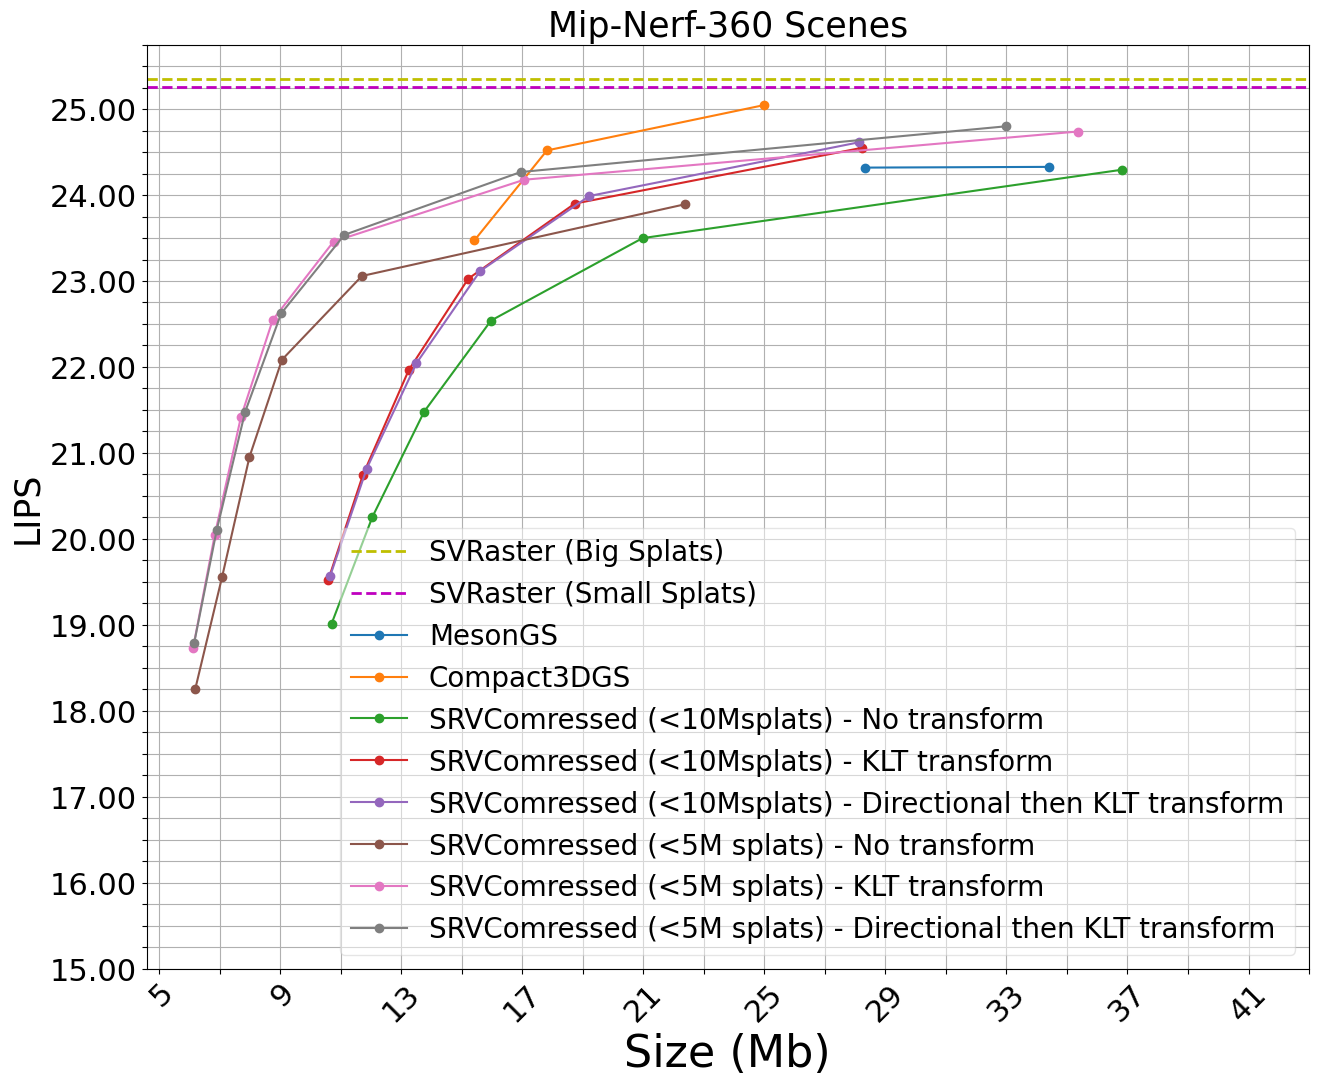

In [39]:
import matplotlib.pylab as plt 
import numpy as np

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 12))

psnr = lambda x: -10 * np.log10(x)

# ## BASELINE 
ax.axhline(y=psnr(df_SVRaster["mse"].mean()), color="y", linestyle='--', linewidth=2, label="SVRaster (Big Splats)")
# ax.axhline(y=25.1179, color="r", linestyle='--', linewidth=2, label="Gaussian Splat") 
ax.axhline(y=psnr(df_SVRaster_small["mse"].mean()), color="m", linestyle='--', linewidth=2, label="SVRaster (Small Splats)")


list_mb=[28.33490975697835, 34.41199345058865]
list_mse=[0.003698760967739922, 0.003691578004687]
ax.plot(list_mb, psnr(list_mse), '-o', label="MesonGS")

list_mb = [24.984521865844727, 17.811832216050888, 15.416125297546387]
list_mse = [0.0031286701518001107, 0.0035324802615301107, 0.004493798714191433]
ax.plot(list_mb, psnr(list_mse), '-o', label="Compact3DGS")

list_mb=[36.83119901021322, 20.970930841233994, 15.962919447157118, 13.75414604610867, 12.043183856540256, 10.691039085388184]
list_psnr=psnr([0.0037193396142281, 0.004468010815730788, 0.0055720513482627665, 0.007111159296396444, 0.009427604585801, 0.012557375957971389])
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - No transform")

list_mb = [28.233379152086044, 18.73141352335612, 15.21045642428928, 13.246741824679905, 11.729202164543999, 10.578036414252388]
list_psnr = psnr([0.003507417783209167, 0.004073118760652467, 0.0049811852150669885, 0.006359530380042122, 0.008425259307252679, 0.011177542721972179])
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - KLT transform")

list_mb = [28.128600226508247, 19.21216434902615, 15.602316326565212, 13.496414502461752, 11.854773945278591, 10.643148422241211]
list_psnr = psnr([0.0034561499992476, 0.003991260898480611, 0.004880274068341311, 0.006248223857892934, 0.008282679221307111, 0.011052484175639933])
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - Directional then KLT transform")


list_mb = [22.38983376820882, 11.697168668111166, 9.052749315897623, 7.979967435201009, 7.073180304633246, 6.186571439107259]
list_psnr = psnr([0.004079495275627567, 0.004944845334660811, 0.0061889015111615, 0.008028294264558533, 0.011079674650083767, 0.014955131618550756])
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - No transform")

list_mb = [35.35847536722819, 17.061622937520344, 10.757858064439562, 8.748948097229004, 7.6954600016276045, 6.829999605814616, 6.112920655144586]
list_psnr = psnr([0.003358058644932, 0.003820811592567333, 0.004509664745082723, 0.005562255570613734, 0.0072196962011369, 0.009903817204668855, 0.013410553353560197])
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - KLT transform")

list_mb = [32.96973482767741, 16.94378587934706, 11.117504331800673, 9.027258131239149, 7.835972044203016, 6.89824104309082, 6.151500701904297]
list_mse = [0.0033116831024474114, 0.0037429238582769777, 0.004428725769945844, 0.005466633561234978, 0.0071163020542572885, 0.009762355293214033, 0.013217444142755934]
ax.plot(list_mb, psnr(list_mse), '-o', label="SRVComressed (<5M splats) - Directional then KLT transform")


############ 
yticks = np.arange(15, 26, step=0.25)
plt.yticks(ticks=yticks, labels=["{:.2f}".format(x) if i%4==0 else "" for i, x in enumerate(yticks)], fontsize=22)

xticks = np.arange(5, 45, step=2)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Size (Mb)', fontsize=32)
plt.ylabel('LIPS', fontsize=25)
plt.title('Mip-Nerf-360 Scenes', fontsize=25)
plt.show()

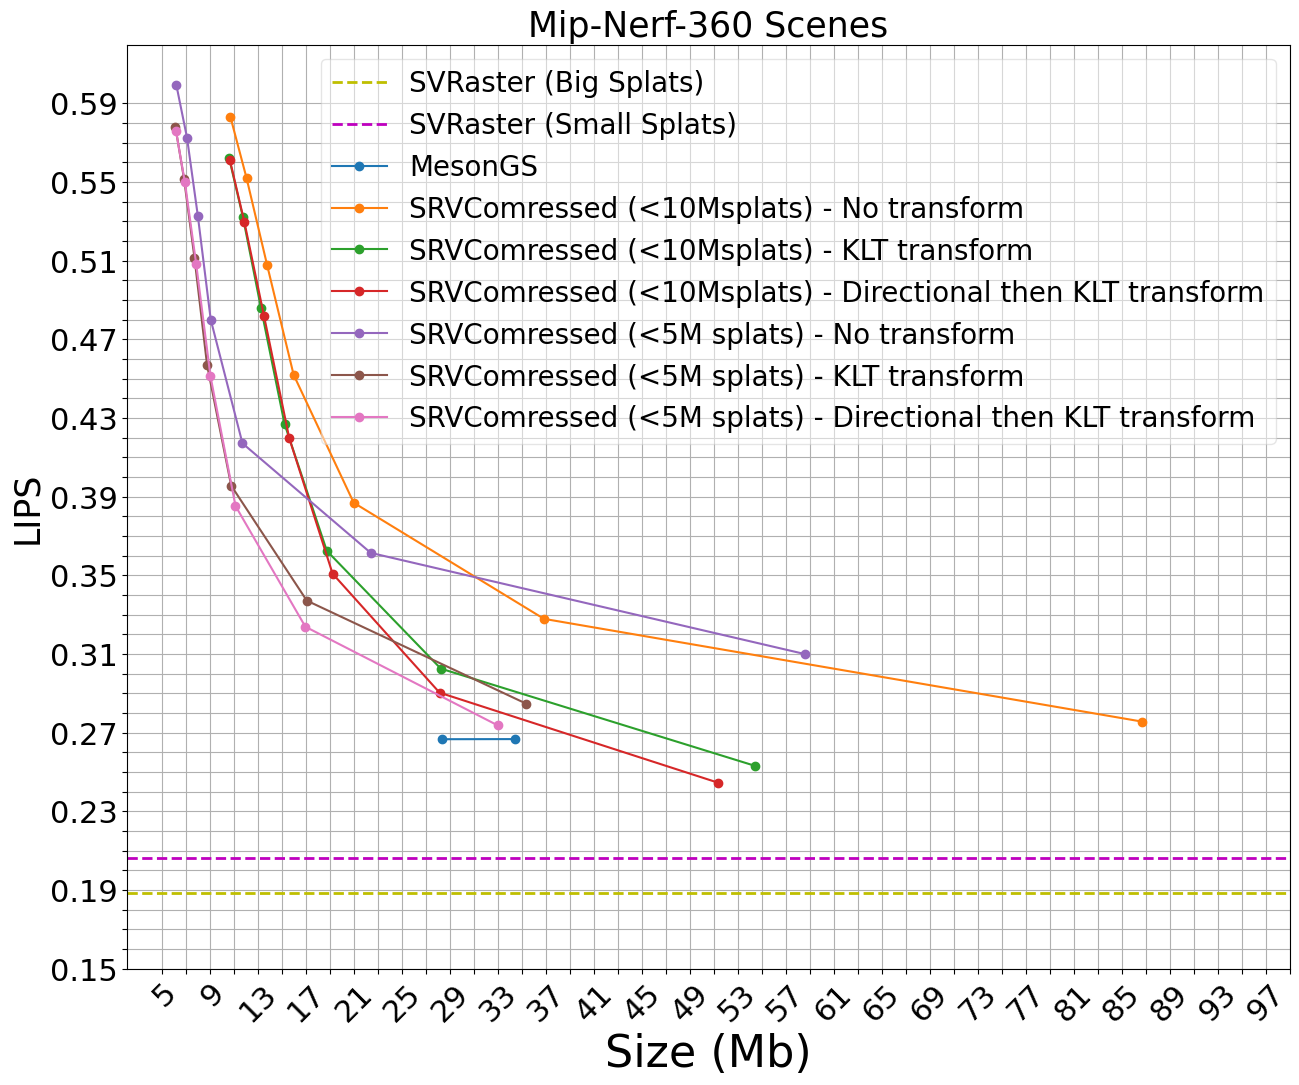

In [16]:
import matplotlib.pylab as plt 
import numpy as np

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 12))


# ## BASELINE 
ax.axhline(y=df_SVRaster["lpips"].mean(), color="y", linestyle='--', linewidth=2, label="SVRaster (Big Splats)")
# ax.axhline(y=25.1179, color="r", linestyle='--', linewidth=2, label="Gaussian Splat") 
ax.axhline(y=df_SVRaster_small["lpips"].mean(), color="m", linestyle='--', linewidth=2, label="SVRaster (Small Splats)")


list_mb=[28.33490975697835, 34.41199345058865]
list_LIPS=[0.2666473983253328, 0.266704931503676]
ax.plot(list_mb, list_LIPS, '-o', label="MesonGS")

list_mb=[86.67328039805095, 36.83119901021322, 20.970930841233994, 15.962919447157118, 13.75414604610867, 12.043183856540256, 10.691039085388184]
list_LIPS=[0.27561760091869314, 0.32784766645629937, 0.3868802863753975, 0.4519458184713495, 0.5076849472900399, 0.5518555010003119, 0.5831209237452399]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<10Msplats) - No transform")

list_mb = [54.39303811391195, 28.233379152086044, 18.73141352335612, 15.21045642428928, 13.246741824679905, 11.729202164543999, 10.578036414252388]
list_LIPS = [0.25317397495046295, 0.30253325060020014, 0.36241848998230997, 0.4268480663225459, 0.48574341014027833, 0.5322942839993451, 0.5622491072435688]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<10Msplats) - KLT transform")

list_mb = [51.33775615692139, 28.128600226508247, 19.21216434902615, 15.602316326565212, 13.496414502461752, 11.854773945278591, 10.643148422241211]
list_LIPS = [0.2445601624924515, 0.29032611268925224, 0.35081176226296384, 0.4196187364300006, 0.4818040613094657, 0.5296989196343875, 0.5612670737350732]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<10Msplats) - Directional then KLT transform")


list_mb = [58.582767486572266, 22.38983376820882, 11.697168668111166, 9.052749315897623, 7.979967435201009, 7.073180304633246, 6.186571439107259]
list_LIPS = [0.30993975680793645, 0.3613916286579716, 0.4170904282826824, 0.47997230004280045, 0.5326374216779435, 0.5725549147056347, 0.5992534302680785]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<5M splats) - No transform")

list_mb = [35.35847536722819, 17.061622937520344, 10.757858064439562, 8.748948097229004, 7.6954600016276045, 6.829999605814616, 6.112920655144586]
list_LIPS = [0.2846997416071874, 0.3371102586527671, 0.39558043077654126, 0.45686599466068134, 0.5114964118804427, 0.5514627329819723, 0.5777557329836155]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<5M splats) - KLT transform")

list_mb = [32.96973482767741, 16.94378587934706, 11.117504331800673, 9.027258131239149, 7.835972044203016, 6.89824104309082, 6.151500701904297]
list_LIPS = [0.273706103654335, 0.3238259200297821, 0.3852457506407918, 0.45133720283556333, 0.5084608997994885, 0.5498183153234454, 0.5760015838825013]
ax.plot(list_mb, list_LIPS, '-o', label="SRVComressed (<5M splats) - Directional then KLT transform")


############ 
yticks = np.arange(0.15, 0.6, step=0.01)
plt.yticks(ticks=yticks, labels=["{:.2f}".format(x) if i%4==0 else "" for i, x in enumerate(yticks)], fontsize=22)

xticks = np.arange(5, 100, step=2)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Size (Mb)', fontsize=32)
plt.ylabel('LIPS', fontsize=25)
plt.title('Mip-Nerf-360 Scenes', fontsize=25)
plt.show()

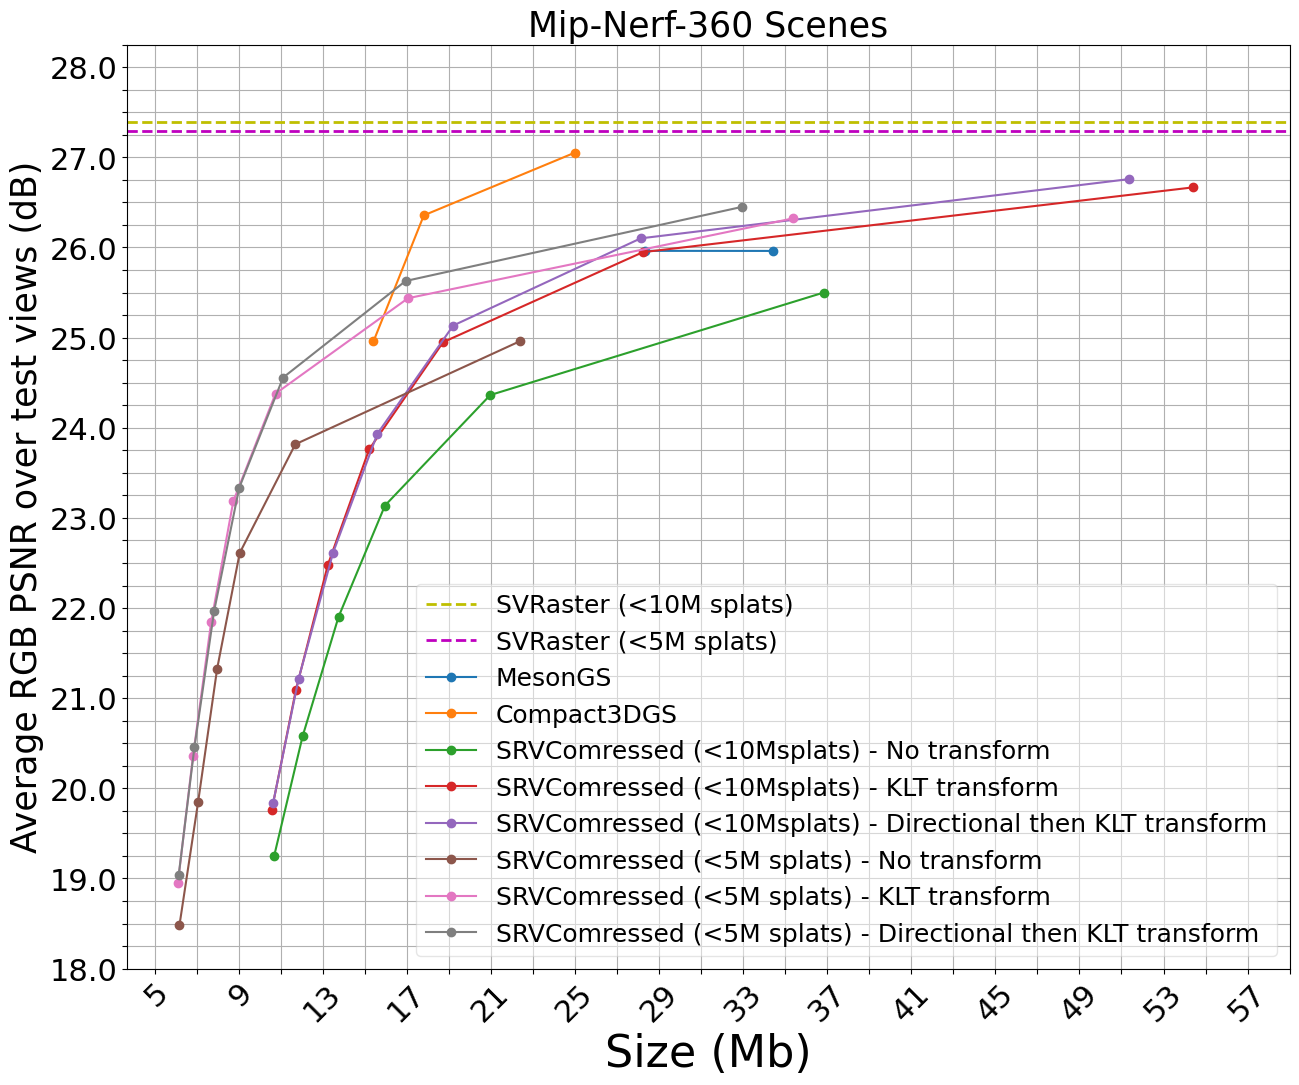

In [49]:
import matplotlib.pylab as plt 
import numpy as np

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 12))


# ## BASELINE 
ax.axhline(y=df_SVRaster["psnr"].mean(), color="y", linestyle='--', linewidth=2, label="SVRaster (<10M splats)")
# ax.axhline(y=25.1179, color="r", linestyle='--', linewidth=2, label="Gaussian Splat") 
ax.axhline(y=df_SVRaster_small["psnr"].mean(), color="m", linestyle='--', linewidth=2, label="SVRaster (<5M splats)")


list_mb=[28.33490975697835, 34.41199345058865]
list_psnr=[25.962563379526603, 25.961681393491457]
ax.plot(list_mb, list_psnr, '-o', label="MesonGS")


list_mb=[24.984521865844727, 17.811832216050888, 15.416125297546387]
list_psnr=[27.050836109270563, 26.356285231114672, 24.95742645998543]
ax.plot(list_mb, list_psnr, '-o', label="Compact3DGS")


list_mb=[36.83119901021322, 20.970930841233994, 15.962919447157118, 13.75414604610867, 12.043183856540256, 10.691039085388184]
list_psnr=[25.499606352317613, 24.362770762830536, 23.136953461503577, 21.901925136800372, 20.57559306550727, 19.249294077824057]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - No transform")

list_mb = [54.39303811391195, 28.233379152086044, 18.73141352335612, 15.21045642428928, 13.246741824679905, 11.729202164543999, 10.578036414252388]
list_psnr = [26.66623701835813, 25.947925051525175, 24.949653914296746, 23.760437208907632, 22.4793321125643, 21.094423993739813, 19.75855354584907]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - KLT transform")

list_mb = [51.33775615692139, 28.128600226508247, 19.21216434902615, 15.602316326565212, 13.496414502461752, 11.854773945278591, 10.643148422241211]
list_psnr = [26.757565276182103, 26.10107176167223, 25.13425567663245, 23.93360194813825, 22.615021251468548, 21.21592753201608, 19.83766019778836]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<10Msplats) - Directional then KLT transform")


list_mb = [22.38983376820882, 11.697168668111166, 9.052749315897623, 7.979967435201009, 7.073180304633246, 6.186571439107259]
list_psnr = [24.960762113135473, 23.816579639347147, 22.610236537183106, 21.327445354432896, 19.846226392532625, 18.480357590048712]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - No transform")

list_mb = [35.35847536722819, 17.061622937520344, 10.757858064439562, 8.748948097229004, 7.6954600016276045, 6.829999605814616, 6.112920655144586]
list_psnr = [26.32189226791066, 25.43724774143466, 24.37883316461521, 23.184360903853488, 21.84465229939421, 20.354439043252807, 18.95062504310131]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - KLT transform")

list_mb = [32.96973482767741, 16.94378587934706, 11.117504331800673, 9.027258131239149, 7.835972044203016, 6.89824104309082, 6.151500701904297]
list_psnr = [26.45144173756676, 25.627948865781494, 24.556842384122834, 23.332943244359015, 21.96664586066415, 20.45367282618406, 19.03787671754206]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - Directional then KLT transform")


############ 
yticks = np.arange(18, 28.5, step=0.25)
plt.yticks(ticks=yticks, labels=["{:.1f}".format(x) if i%4==0 else "" for i, x in enumerate(yticks)], fontsize=22)

xticks = np.arange(5, 60, step=2)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 18})
plt.xlabel('Size (Mb)', fontsize=32)
plt.ylabel('Average RGB PSNR over test views (dB)', fontsize=25)
plt.title('Mip-Nerf-360 Scenes', fontsize=25)
plt.show()

# PLOT NERF SYNTHETIC

In [3]:
import pandas as pd
import matplotlib.pylab as plt

results_csv_folder = "/home/dotamthuc/Works/Projects/Compress3DGS/Experiments/exp_data/"

#
df_SVRaster = pd.read_csv(f"{results_csv_folder}/SVRaster/results_big_nerf_synthetic_SVRaster.csv")
df_SVRaster_small = pd.read_csv(f"{results_csv_folder}/SVRaster/results_small_nerf_synthetic_SVRasterSmall.csv")

#
df_mesonGS = pd.concat([
    pd.read_csv(f"{results_csv_folder}/MesonGS/results_mesonGS_nerf_synthetic_MesonGS.csv"),
    pd.read_csv(f"{results_csv_folder}/MesonGS/results_mesonGS_part_2_nerf_synthetic_MesonGS.csv"),
])
df_compact3DGS = pd.read_csv(f"{results_csv_folder}/Compact3DGS/results_nerf_synthetic_Compact3DGS.csv")

#
df_SVRasterCompressed_DirColorv           = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_nerf_synthetic_SVRasterCompressed-DirColorv.csv")
df_SVRasterCompressed_NoShsTransform      = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_nerf_synthetic_SVRasterCompressed-NoShsTransform.csv")
df_SVRasterCompressed                     = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_nerf_synthetic_SVRasterCompressed.csv")
df_SVRasterSmallCompressed_DirColorv      = pd.read_csv(f"{results_csv_folder}SVComression/results_tunningV03_nerf_synthetic_SVRasterSmallCompressed-DirColorv.csv")
df_SVRasterSmallCompressed_NoShsTransform = pd.read_csv(f"{results_csv_folder}SVComression/results_V01_nerf_synthetic_SVRasterSmallCompressed-NoShsTransform.csv")
df_SVRasterSmallCompressed                = pd.read_csv(f"{results_csv_folder}SVComression/results_tunningV03_nerf_synthetic_SVRasterSmallCompressed.csv")

In [10]:
list_mb=[]
list_psnr=[]
points = [
    "config=='config00'",
    "config=='config01'",
    "config=='config02'"
]
for query in points:
    print(f"df_compact3DGS query={query}")
    size, psnr = df_compact3DGS.query(query)[["Size_MB", "psnr"]].mean()
    list_mb.append(size)
    list_psnr.append(psnr)

print(list_mb)
print(list_psnr)


df_compact3DGS query=config=='config00'
df_compact3DGS query=config=='config01'
df_compact3DGS query=config=='config02'
[2.3602349758148193, 1.7723894119262695, 1.5735442638397217]
[32.89560377240181, 32.57171383976936, 31.349844270944594]


In [6]:

list_mb=[]
list_psnr=[]
points = [
    "config=='config00'",
    "config=='config01'",
    "config=='config02'",
    "config=='config03'",
    "config=='config04'",
    "config=='config05'",
    "config=='config06'"
]
for query in points:
    print(f"df_SVRasterCompressed_DirColorv query={query}")
    size, psnr = df_SVRasterSmallCompressed_DirColorv.query(query)[["Size_MB", "psnr"]].mean()
    list_mb.append(size)
    list_psnr.append(psnr)

print(list_mb)
print(list_psnr)



df_SVRasterCompressed_DirColorv query=config=='config00'
df_SVRasterCompressed_DirColorv query=config=='config01'
df_SVRasterCompressed_DirColorv query=config=='config02'
df_SVRasterCompressed_DirColorv query=config=='config03'
df_SVRasterCompressed_DirColorv query=config=='config04'
df_SVRasterCompressed_DirColorv query=config=='config05'
df_SVRasterCompressed_DirColorv query=config=='config06'
[4.393751859664917, 2.0124841928482056, 1.1756433248519897, 0.901374340057373, 0.7565861940383911, 0.6658225059509277, 0.606414794921875]
[31.895745353698732, 31.01582504630089, 29.82283958315849, 28.44921931147575, 26.95919140100479, 25.42086158871651, 23.88021502494812]


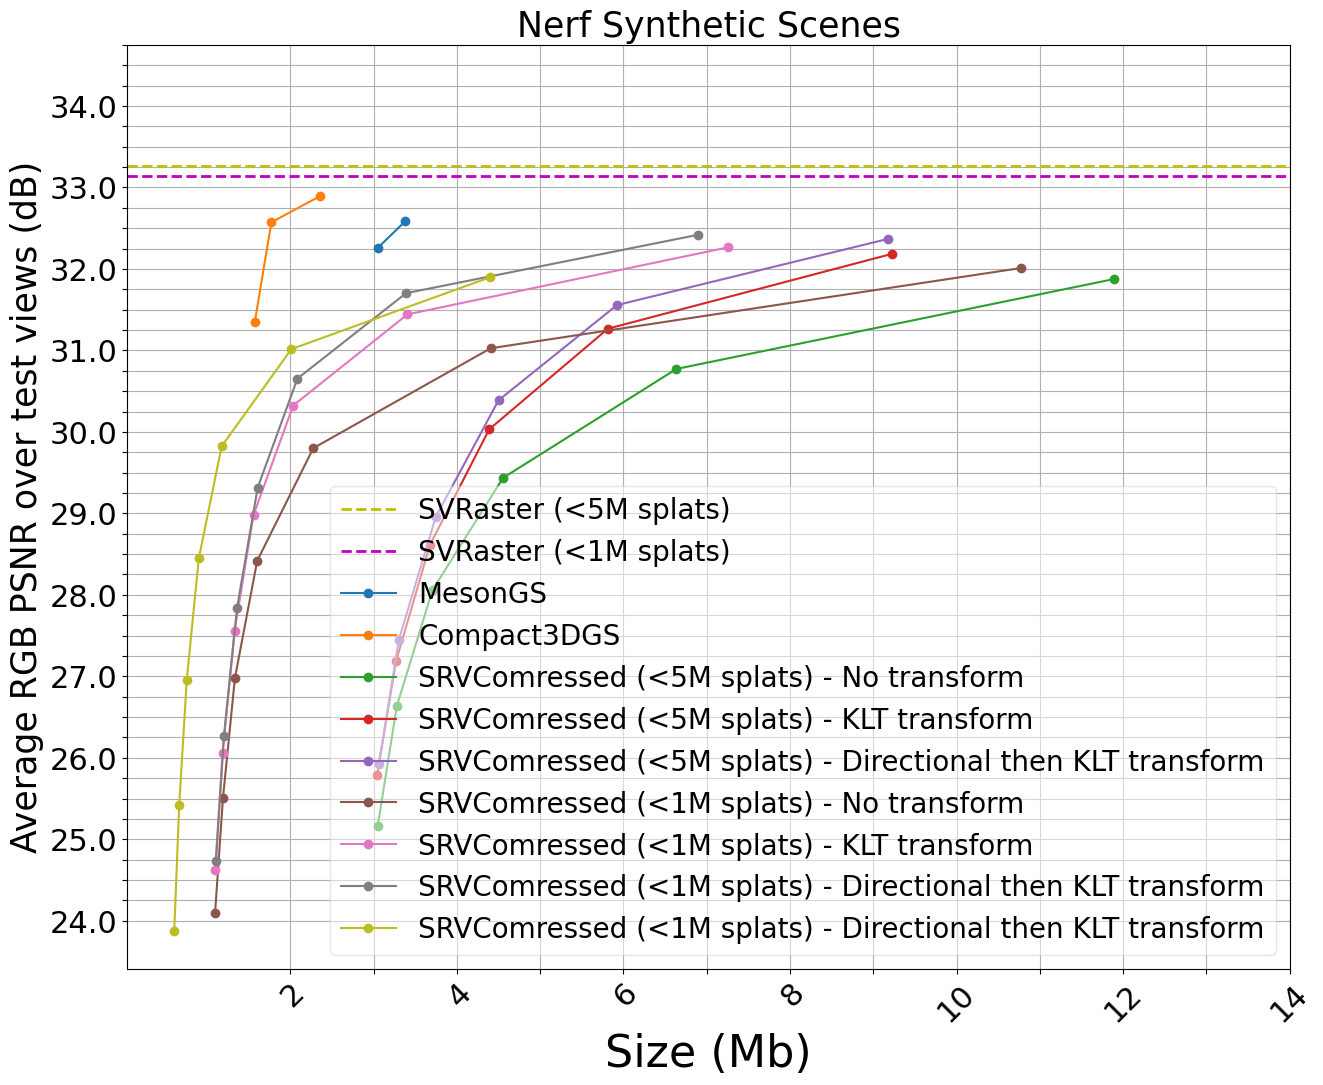

In [8]:
import matplotlib.pylab as plt 
import numpy as np

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(15, 12))


# ## BASELINE 
ax.axhline(y=df_SVRaster["psnr"].mean(), color="y", linestyle='--', linewidth=2, label="SVRaster (<5M splats)")
# ax.axhline(y=25.1179, color="r", linestyle='--', linewidth=2, label="Gaussian Splat") 
ax.axhline(y=df_SVRaster_small["psnr"].mean(), color="m", linestyle='--', linewidth=2, label="SVRaster (<1M splats)")


list_mb=[3.051652, 3.380643]
list_psnr=[32.259981, 32.585670]
ax.plot(list_mb, list_psnr, '-o', label="MesonGS")

list_mb=[2.3602349758148193, 1.7723894119262695, 1.5735442638397217]
list_psnr=[32.89560377240181, 32.57171383976936, 31.349844270944594]
ax.plot(list_mb, list_psnr, '-o', label="Compact3DGS")


list_mb=[11.889164328575134, 6.635035514831543, 4.553641200065613, 3.707211494445801, 3.278614640235901, 3.049076199531555]
list_psnr=[31.875420103073118, 30.77241705417633, 29.435088183879852, 28.05988182902336, 26.635139062404633, 25.162210202217103]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - No transform")

list_mb = [9.221434831619263, 5.813037276268005, 4.388183355331421, 3.6780487298965454, 3.2683589458465576, 3.0422608852386475]
list_psnr = [32.184044144153596, 31.26646520972252, 30.03197952270508, 28.617230870723724, 27.183578441143034, 25.784010496139526]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - KLT transform")

list_mb = [9.177408456802368, 5.921729803085327, 4.4995445013046265, 3.7456109523773193, 3.3033350706100464, 3.0628708600997925]
list_psnr = [32.36847269892692, 31.556177496910095, 30.387588495016097, 28.95535342335701, 27.45147301912308, 25.929678331613538]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<5M splats) - Directional then KLT transform")

list_mb = [10.767943739891052, 4.406251907348633, 2.2759565114974976, 1.6024165153503418, 1.3348063230514526, 1.190846562385559, 1.0960278511047363]
list_psnr = [32.010150510072705, 31.026383260488508, 29.800477548837662, 28.418236672878265, 26.979956718683244, 25.50240354061127, 24.090594305992127]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<1M splats) - No transform") 

list_mb = [7.256751179695129, 3.406158685684204, 2.034014582633972, 1.558026909828186, 1.3298527002334595, 1.187422275543213, 1.096863865852356]
list_psnr = [32.26481579899788, 31.442087770700454, 30.323266413211822, 28.98066479921341, 27.55198808193207, 26.06315036177635, 24.623999565839767]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<1M splats) - KLT transform")

list_mb = [6.894618988037109, 3.388818383216858, 2.0850800275802612, 1.608224868774414, 1.3598527908325195, 1.202958583831787, 1.1076200008392334]
list_psnr = [32.418449542522424, 31.701808689832685, 30.6536466884613, 29.31615522623062, 27.83846328616142, 26.270159022808077, 24.7390726685524]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<1M splats) - Directional then KLT transform")

list_mb = [4.393751859664917, 2.0124841928482056, 1.1756433248519897, 0.901374340057373, 0.7565861940383911, 0.6658225059509277, 0.606414794921875]
list_psnr = [31.895745353698732, 31.01582504630089, 29.82283958315849, 28.44921931147575, 26.95919140100479, 25.42086158871651, 23.88021502494812]
ax.plot(list_mb, list_psnr, '-o', label="SRVComressed (<1M splats) - Directional then KLT transform")


############ 
yticks = np.arange(24, 35, step=0.25)
plt.yticks(ticks=yticks, labels=["{:.1f}".format(x) if i%4==0 else "" for i, x in enumerate(yticks)], fontsize=22)

xticks = np.arange(2, 15, step=1)
plt.xticks(ticks=xticks, labels=["{:2d}".format(x) if i%2==0 else "" for i, x in enumerate(xticks)], rotation=45, fontsize=22)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Size (Mb)', fontsize=32)
plt.ylabel('Average RGB PSNR over test views (dB)', fontsize=25)
plt.title('Nerf Synthetic Scenes', fontsize=25)

# plt.savefig("../../Figures/NerfSyntheticResults.png")
plt.show()